In [324]:
import pandas as pd
import numpy as np

In [325]:
df = pd.read_csv("hotel_bookings.csv")

In [326]:
df.head(10)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.0,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.0,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.5,0,0,Canceled,2015-04-22


In [327]:
df['customer_type'].unique()

array(['Transient', 'Contract', 'Transient-Party', 'Group'], dtype=object)

In [328]:
df['stays_in_weekend_nights'].unique()

array([ 0,  1,  2,  4,  3,  6, 13,  8,  5,  7, 12,  9, 16, 18, 19, 10, 14])

In [329]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [330]:
df.shape


(119390, 32)

In [331]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [332]:
df['children'].unique()

array([ 0.,  1.,  2., 10.,  3., nan])

In [333]:
df['children']=df['children'].fillna(0)

In [334]:
df=df.drop(columns=['company'])

In [335]:
df['agent']=df['agent'].fillna(0)

In [336]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [337]:
df["country"] = df["country"].fillna("Unknown")

In [338]:
df.duplicated().sum()

np.int64(32001)

In [339]:
df.drop_duplicates(inplace=True)

In [340]:
df.shape

(87389, 31)

In [341]:
df["is_canceled"].value_counts()

,count
is_canceled,
0,63364
1,24025


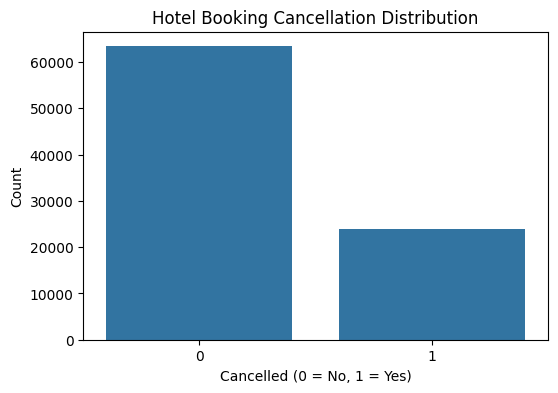

In [342]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="is_canceled", data=df)
plt.title("Hotel Booking Cancellation Distribution")
plt.xlabel("Cancelled (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

In [343]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000,87389.000000
mean,0.274920,79.897195,2016.210313,26.837760,15.815698,1.005321,2.625548,1.875842,0.138644,0.010825,0.039078,0.030416,0.184005,0.271625,81.008193,0.749625,106.339070,0.084233,0.698589
std,0.446477,86.053274,0.686094,13.674352,8.835244,1.031935,2.053591,0.626490,0.455888,0.113601,0.193782,0.369160,1.731962,0.727270,109.946820,10.016130,55.013097,0.281544,0.831950
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,72.000000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.000000,98.100000,0.000000,0.000000
75%,1.000000,125.000000,2017.000000,37.000000,23.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,0.000000,134.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,391.000000,5400.000000,8.000000,5.000000


In [344]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col}: {df[col].nunique()} unique values")

hotel: 2 unique values
arrival_date_month: 12 unique values
meal: 5 unique values
country: 178 unique values
market_segment: 8 unique values
distribution_channel: 5 unique values
reserved_room_type: 10 unique values
assigned_room_type: 12 unique values
deposit_type: 3 unique values
customer_type: 4 unique values
reservation_status: 3 unique values
reservation_status_date: 926 unique values


In [345]:
df.drop(columns=["reservation_status", "reservation_status_date"], inplace=True)

In [346]:
for col in df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(df[col].value_counts())


hotel
hotel
City Hotel      53426
Resort Hotel    33963
Name: count, dtype: int64

arrival_date_month
arrival_date_month
August       11257
July         10056
May           8354
April         7908
June          7765
March         7513
October       6934
September     6689
February      6097
December      5130
November      4993
January       4693
Name: count, dtype: int64

meal
meal
BB           67971
SC            9481
HB            9085
Undefined      492
FB             360
Name: count, dtype: int64

country
country
PRT    27449
GBR    10432
FRA     8837
ESP     7252
DEU     5387
       ...  
MRT        1
KIR        1
SDN        1
ATF        1
SLE        1
Name: count, Length: 178, dtype: int64

market_segment
market_segment
Online TA        51615
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4208
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

distribution_channel
distribution_channel
TA/TO    

In [347]:
df["hotel"] = df["hotel"].map({
    "City Hotel": 0,
    "Resort Hotel": 1
})

In [348]:
df["hotel"].value_counts()

,count
hotel,
0,53426
1,33963


In [349]:
categorical_cols = [
    "arrival_date_month",
    "meal",
    "market_segment",
    "distribution_channel",
    "reserved_room_type",
    "assigned_room_type",
    "deposit_type",

    "customer_type"
]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [350]:
df["country"].value_counts().head(20)

,count
country,
PRT,27449
GBR,10432
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081
BRA,1995


In [351]:
threshold = 1500

country_counts = df["country"].value_counts()
rare_countries = country_counts[country_counts < threshold].index

df["country"] = df["country"].apply(
    lambda x: "Other" if x in rare_countries else x
)

In [352]:
df["country"] = df["country"].replace(rare_countries, "Other")

In [353]:
df["country"].value_counts()

,count
country,
PRT,27449
Other,12518
GBR,10432
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081


In [354]:
df["country"].value_counts().head(20)

,count
country,
PRT,27449
Other,12518
GBR,10432
FRA,8837
ESP,7252
DEU,5387
ITA,3066
IRL,3016
BEL,2081


In [355]:
categorical_cols = [

    'country'

]

df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

In [356]:
df.select_dtypes(include="object").columns

Index([], dtype='object')

In [357]:
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

In [358]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [359]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (69911, 82)
X_test : (17478, 82)
y_train: (69911,)
y_test : (17478,)


In [360]:
#without pruning nad of full tree

In [361]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [362]:
train_acc = dt.score(X_train, y_train)
print("Training Accuracy:", train_acc)

Training Accuracy: 0.9976970719915321


In [363]:
test_acc = dt.score(X_test, y_test)
print("Testing Accuracy:", test_acc)

Testing Accuracy: 0.7979745966357706


In [364]:
y_pred = dt.predict(X_test)

In [365]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.7979745966357706
Precision: 0.629418935392117
Recall   : 0.64474505723205
F1 Score : 0.6369898221445461

Confusion Matrix
[[10849  1824]
 [ 1707  3098]]

Classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86     12673
           1       0.63      0.64      0.64      4805

    accuracy                           0.80     17478
   macro avg       0.75      0.75      0.75     17478
weighted avg       0.80      0.80      0.80     17478



In [366]:
for depth in [8, 10, 12, 15, 18]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    print(f"Max Depth = {depth}")
    print("Train Accuracy:", model.score(X_train, y_train))
    print("Test Accuracy :", model.score(X_test, y_test))
    print("-"*40)

Max Depth = 8
Train Accuracy: 0.7283260145041552
Test Accuracy : 0.7194759125758096
----------------------------------------
Max Depth = 10
Train Accuracy: 0.7566048261360873
Test Accuracy : 0.7424190410802152
----------------------------------------
Max Depth = 12
Train Accuracy: 0.8015619859535695
Test Accuracy : 0.7769195560132738
----------------------------------------
Max Depth = 15
Train Accuracy: 0.8350045057287122
Test Accuracy : 0.7913948964412404
----------------------------------------
Max Depth = 18
Train Accuracy: 0.8676317031654532
Test Accuracy : 0.794770568714956
----------------------------------------


In [367]:
for split in [2, 5, 10, 20, 30]:
    model = DecisionTreeClassifier(
        max_depth=15,
        min_samples_split=split,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    print(f"min_samples_split = {split}")
    print("Train Accuracy:", model.score(X_train, y_train))
    print("Test Accuracy :", model.score(X_test, y_test))
    print("-"*40)

min_samples_split = 2
Train Accuracy: 0.8350045057287122
Test Accuracy : 0.7913948964412404
----------------------------------------
min_samples_split = 5
Train Accuracy: 0.8325299309121598
Test Accuracy : 0.7885913720105275
----------------------------------------
min_samples_split = 10
Train Accuracy: 0.8281815451073508
Test Accuracy : 0.7871610024030209
----------------------------------------
min_samples_split = 20
Train Accuracy: 0.8237473358984995
Test Accuracy : 0.7872754319716214
----------------------------------------
min_samples_split = 30
Train Accuracy: 0.8211440259758837
Test Accuracy : 0.787847579814624
----------------------------------------


In [368]:
for leaf in [1, 2, 5, 10]:
    model = DecisionTreeClassifier(
        max_depth=15,
        min_samples_leaf=leaf,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    print(f"min_samples_leaf = {leaf}")
    print("Train Accuracy:", model.score(X_train, y_train))
    print("Test Accuracy :", model.score(X_test, y_test))
    print("-"*40)

min_samples_leaf = 1
Train Accuracy: 0.8350045057287122
Test Accuracy : 0.7913948964412404
----------------------------------------
min_samples_leaf = 2
Train Accuracy: 0.8306990316259244
Test Accuracy : 0.7875042911088225
----------------------------------------
min_samples_leaf = 5
Train Accuracy: 0.824376707528143
Test Accuracy : 0.7856734180112142
----------------------------------------
min_samples_leaf = 10
Train Accuracy: 0.8198995866172706
Test Accuracy : 0.786302780638517
----------------------------------------


In [369]:
for crit in ["gini", "entropy"]:
    model = DecisionTreeClassifier(
        criterion=crit,
        max_depth=15,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train, y_train)

    print(f"Criterion = {crit}")
    print("Train Accuracy:", model.score(X_train, y_train))
    print("Test Accuracy :", model.score(X_test, y_test))
    print("-"*40)

Criterion = gini
Train Accuracy: 0.8350045057287122
Test Accuracy : 0.7913948964412404
----------------------------------------
Criterion = entropy
Train Accuracy: 0.828224456809372
Test Accuracy : 0.7888774459320288
----------------------------------------


In [370]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pre_pruned_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=10,
    random_state=42
)

pre_pruned_tree.fit(X_train, y_train)

y_train_pred = pre_pruned_tree.predict(X_train)
y_test_pred = pre_pruned_tree.predict(X_test)


print("Training Accuracy :", accuracy_score(y_train, y_train_pred))
print("Training Precision:", precision_score(y_train, y_train_pred))
print("Training Recall   :", recall_score(y_train, y_train_pred))
print("Training F1 Score :", f1_score(y_train, y_train_pred))

print("-"*50)

print("Testing Accuracy  :", accuracy_score(y_test, y_test_pred))
print("Testing Precision :", precision_score(y_test, y_test_pred))
print("Testing Recall    :", recall_score(y_test, y_test_pred))
print("Testing F1 Score  :", f1_score(y_test, y_test_pred))

Training Accuracy : 0.8261360873110097
Training Precision: 0.7051512863697079
Training Recall   : 0.6317377731529656
Training F1 Score : 0.6664288262575812
--------------------------------------------------
Testing Accuracy  : 0.8150818171415494
Testing Precision : 0.6802658721063488
Testing Recall    : 0.6176899063475546
Testing F1 Score  : 0.6474694589877836


In [371]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

In [372]:
alphas = [0.0, 0.0001, 0.0005, 0.001, 0.005, 0.01]

In [373]:
results = []

for alpha in alphas:

    model = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        ccp_alpha=alpha
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    results.append([alpha, train_acc, test_acc])

results = pd.DataFrame(
    results,
    columns=["ccp_alpha", "Train Accuracy", "Test Accuracy"]
)

results

,ccp_alpha,Train Accuracy,Test Accuracy
0,0.0000,0.997683,0.803067
1,0.0001,0.807942,0.790022
2,0.0005,0.798258,0.788591
3,0.0010,0.784197,0.778235
4,0.0050,0.699818,0.693157
5,0.0100,0.660340,0.656254


In [374]:
results.sort_values(by="Test Accuracy", ascending=False)

,ccp_alpha,Train Accuracy,Test Accuracy
0,0.0000,0.997683,0.803067
1,0.0001,0.807942,0.790022
2,0.0005,0.798258,0.788591
3,0.0010,0.784197,0.778235
4,0.0050,0.699818,0.693157
5,0.0100,0.660340,0.656254


In [375]:
post_pruned_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=0.001
)

post_pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.001, random_state=42)

In [376]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = post_pruned_tree.predict(X_test)

print("Training Accuracy:", post_pruned_tree.score(X_train, y_train))
print("Testing Accuracy :", post_pruned_tree.score(X_test, y_test))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Training Accuracy: 0.8038506100613637
Testing Accuracy : 0.8010641949879849

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.93      0.87     12673
           1       0.71      0.46      0.56      4805

    accuracy                           0.80     17478
   macro avg       0.77      0.70      0.72     17478
weighted avg       0.79      0.80      0.79     17478


Confusion Matrix
[[11770   903]
 [ 2574  2231]]


In [377]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

alphas = [0.0, 0.0001, 0.0005, 0.001, 0.002, 0.005]

for alpha in alphas:

    post_pruned_tree = DecisionTreeClassifier(
        criterion="gini",
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=10,
        ccp_alpha=alpha,
        random_state=42
    )

    post_pruned_tree.fit(X_train, y_train)

    y_train_pred = post_pruned_tree.predict(X_train)
    y_test_pred = post_pruned_tree.predict(X_test)

    print("="*60)
    print(f"ccp_alpha = {alpha}")

    print("Train Accuracy :", round(accuracy_score(y_train, y_train_pred),4))
    print("Test Accuracy  :", round(accuracy_score(y_test, y_test_pred),4))

    print("Train Precision:", round(precision_score(y_train, y_train_pred),4))
    print("Test Precision :", round(precision_score(y_test, y_test_pred),4))

    print("Train Recall   :", round(recall_score(y_train, y_train_pred),4))
    print("Test Recall    :", round(recall_score(y_test, y_test_pred),4))

    print("Train F1 Score :", round(f1_score(y_train, y_train_pred),4))
    print("Test F1 Score  :", round(f1_score(y_test, y_test_pred),4))

ccp_alpha = 0.0
Train Accuracy : 0.8261
Test Accuracy  : 0.8151
Train Precision: 0.7052
Test Precision : 0.6803
Train Recall   : 0.6317
Test Recall    : 0.6177
Train F1 Score : 0.6664
Test F1 Score  : 0.6475
ccp_alpha = 0.0001
Train Accuracy : 0.8247
Test Accuracy  : 0.8159
Train Precision: 0.7021
Test Precision : 0.6815
Train Recall   : 0.6292
Test Recall    : 0.62
Train F1 Score : 0.6637
Test F1 Score  : 0.6493
ccp_alpha = 0.0005
Train Accuracy : 0.8174
Test Accuracy  : 0.811
Train Precision: 0.6953
Test Precision : 0.6806
Train Recall   : 0.5979
Test Recall    : 0.5886
Train F1 Score : 0.643
Test F1 Score  : 0.6312
ccp_alpha = 0.001
Train Accuracy : 0.8039
Test Accuracy  : 0.8011
Train Precision: 0.7203
Test Precision : 0.7119
Train Recall   : 0.4684
Test Recall    : 0.4643
Train F1 Score : 0.5676
Test F1 Score  : 0.562
ccp_alpha = 0.002
Train Accuracy : 0.791
Test Accuracy  : 0.7876
Train Precision: 0.6189
Test Precision : 0.6116
Train Recall   : 0.6237
Test Recall    : 0.6235
Trai

In [385]:
post_pruned_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=10,
    ccp_alpha=0.00005,
    random_state=42
)

post_pruned_tree.fit(X_train, y_train)

DecisionTreeClassifier(ccp_alpha=5e-05, max_depth=10, min_samples_leaf=10,
                       min_samples_split=5, random_state=42)

In [386]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Predictions
y_train_pred = post_pruned_tree.predict(X_train)
y_test_pred = post_pruned_tree.predict(X_test)

# Training Metrics
print("Training Accuracy :", accuracy_score(y_train, y_train_pred))
print("Training Precision:", precision_score(y_train, y_train_pred))
print("Training Recall   :", recall_score(y_train, y_train_pred))
print("Training F1 Score :", f1_score(y_train, y_train_pred))

print("-"*50)

# Testing Metrics
print("Testing Accuracy  :", accuracy_score(y_test, y_test_pred))
print("Testing Precision :", precision_score(y_test, y_test_pred))
print("Testing Recall    :", recall_score(y_test, y_test_pred))
print("Testing F1 Score  :", f1_score(y_test, y_test_pred))

print("-"*50)

# Classification Report
print("Classification Report\n")
print(classification_report(y_test, y_test_pred))

Training Accuracy : 0.825621146886756
Training Precision: 0.7042720139494333
Training Recall   : 0.6304370447450572
Training F1 Score : 0.6653122855181881
--------------------------------------------------
Testing Accuracy  : 0.8147957432200481
Testing Precision : 0.6798990362551629
Testing Recall    : 0.6166493236212279
Testing F1 Score  : 0.6467314198406635
--------------------------------------------------
Classification Report

              precision    recall  f1-score   support

           0       0.86      0.89      0.87     12673
           1       0.68      0.62      0.65      4805

    accuracy                           0.81     17478
   macro avg       0.77      0.75      0.76     17478
weighted avg       0.81      0.81      0.81     17478



In [380]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": pre_pruned_tree.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance.head(20)

,Feature,Importance
80,country_PRT,0.191388
18,total_of_special_requests,0.153335
1,lead_time,0.148531
39,market_segment_Online TA,0.099155
17,required_car_parking_spaces,0.090280
14,agent,0.079196
2,arrival_date_year,0.047550
65,deposit_type_Non Refund,0.040981
11,previous_cancellations,0.030736
68,customer_type_Transient,0.026894


In [381]:
df.groupby("is_canceled")["lead_time"].mean()

,lead_time
is_canceled,
0,70.106543
1,105.719251


In [382]:
df.groupby("is_canceled")["adr"].mean()

,adr
is_canceled,
0,102.003997
1,117.772476


In [383]:
df.groupby("is_canceled")["total_of_special_requests"].mean()

,total_of_special_requests
is_canceled,
0,0.760353
1,0.535692


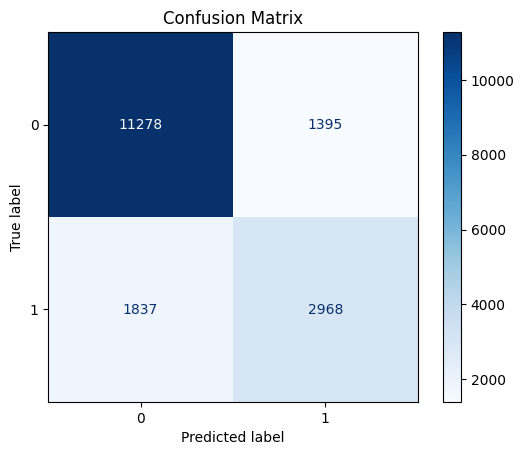

In [384]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = pre_pruned_tree.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()